### Импорт библиотек

In [ ]:
!pip install scipy==1.11.1  scikit-learn wordcloud seaborn spacy typing_extensions==4.8.0

In [ ]:
!pip install gensim adjustText

In [ ]:
from time import time
import nltk
from nltk.corpus import stopwords
from nltk.corpus import wordnet as wn
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.probability import FreqDist
from nltk import pos_tag
from nltk.collocations import BigramAssocMeasures, BigramCollocationFinder

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('averaged_perceptron_tagger_ru')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

import spacy
import sklearn
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from wordcloud import WordCloud

import string
import pandas as pd
import numpy as np
import regex as re
from charset_normalizer import detect

from adjustText import adjust_text
from collections import defaultdict

from time import time
from collections import defaultdict, Counter

import logging
import gensim
from gensim.models import FastText
from gensim.models.phrases import Phrases, Phraser
from gensim.models import KeyedVectors
import multiprocessing
logging.basicConfig(format="%(levelname)s - %(asctime)s: %(message)s", datefmt= '%H:%M:%S', level=logging.INFO)



In [ ]:
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
nlp = spacy.load("en_core_web_sm")
eng_stopwords = set(stopwords.words('english'))

## **Анализ данных**

### Чтение текста

In [ ]:
file_path = '' # путь к тексту в txt

In [ ]:
with open(file_path, 'rb') as f:
    raw_data = f.read()
encoding = detect(raw_data)['encoding']
print(f"Определенная кодировка: {encoding}")

Определенная кодировка: utf-8


In [ ]:
with open(file_path, "r", encoding="utf-8") as f:
    text = f.read()

text = text.lower()

words = re.findall(r"[а-яa-zё]+", text)

total_words = len(words)
print("Общее количество слов:", total_words)

Общее количество слов: 158107


In [ ]:
with open(file_path, 'r', encoding=encoding) as f:
    lines = [line.strip() for line in f if line.strip()]

df = pd.DataFrame(lines, columns=["input"])

### Предобработка

In [ ]:
def nltk_pos_tag(word):
    # Получает POS для одного слова и преобразует NLTK-тег в формат для WordNetLemmatizer
    tag = nltk.pos_tag([word])[0][1]
    if tag.startswith('J'):
        return 'a'
    elif tag.startswith('V'):
        return 'v'
    elif tag.startswith('N'):
        return 'n'
    elif tag.startswith('R'):
        return 'r'
    else:
        return 'n'

In [ ]:
def preprocessing(line,
                  remove_punctuation=True,
                  remove_stopwords=True,
                  normalisation=True,
                  use_spacy=True):
    line = line.lower()
    line = re.sub('\n\t', ' ', line)
    line = re.sub(r'[^а-яёa-z0-9\s{}]'.format(string.punctuation), '', line)
    if remove_punctuation:
        line = re.sub(r"[{}]".format(string.punctuation), " ", line)
    words = [x for x in re.split(r'[ ]', line) if x]

    if remove_stopwords:
        stop_words = eng_stopwords
        words = [x for x in words if x not in stop_words]

    lemmas = []
    if normalisation:
        if use_spacy:
            doc = nlp(' '.join(words))
            lemmas = [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]
        else:
            lemmatizer = WordNetLemmatizer()
            for x in words:
                pos = nltk_pos_tag(x)
                lemmas.append(lemmatizer.lemmatize(x, pos))
    else:
        lemmas = words

    return ' '.join(lemmas)


Вызов функции предобработки и создание датафрейма



In [ ]:
t = time()
txt = [preprocessing(x) for x in df['input']]

print('Время для чистки: {} мин.'.format(round((time() - t) / 60, 2)))

Время для чистки: 0.91 мин.


In [ ]:
df_clean = pd.DataFrame({'clean': txt})

In [ ]:
df_clean.shape

(3546, 1)

In [ ]:
# Не убрались обозначения глав и конец, поэтому убираем вручную
df_clean = df_clean[df_clean['clean'].str.strip().str.lower().isin(['chapter', 'end']) == False]

In [ ]:
''' Cохранить датафрейм в формате csv '''
df_clean.to_csv('/lemmatized_rebecca.csv', sep='\t', index=False)

In [ ]:
''' Чтение сохранненого датафрейма'''
df_clean = pd.read_csv('/lemmatized_rebecca.csv', sep='\t')

### Частотный анализ

In [ ]:
df_clean['clean'] = df_clean['clean'].astype(str)

In [ ]:
# Выводим список из списков лемм по каждой строке в датафрейме
sent = [row.split() for row in df_clean['clean']]
sent

[['night',
  'dream',
  'go',
  'manderley',
  'stand',
  'iron',
  'gate',
  'lead',
  'drive',
  'enter',
  'way',
  'bar',
  'padlock',
  'chain',
  'gate',
  'call',
  'dream',
  'lodge',
  'keeper',
  'answer',
  'peer',
  'close',
  'rusted',
  'spoke',
  'gate',
  'see',
  'lodge',
  'uninhabited'],
 ['smoke',
  'come',
  'chimney',
  'little',
  'lattice',
  'window',
  'gap',
  'forlorn',
  'like',
  'dreamer',
  'possess',
  'sudden',
  'supernatural',
  'power',
  'pass',
  'like',
  'spirit',
  'barrier',
  'drive',
  'wind',
  'away',
  'twisting',
  'turn',
  'advance',
  'aware',
  'change',
  'come',
  'narrow',
  'unkempt',
  'drive',
  'know',
  'puzzle',
  'understand',
  'bent',
  'head',
  'avoid',
  'low',
  'swing',
  'branch',
  'tree',
  'realise',
  'happen',
  'nature',
  'come',
  'little',
  'little',
  'stealthy',
  'insidious',
  'way',
  'encroach',
  'drive',
  'long',
  'tenacious',
  'finger',
  'wood',
  'menace',
  'past',
  'triumph',
  'end',
  'c

In [ ]:
phrases = Phrases(sent, min_count=10, progress_per=5000)
bigram = Phraser(phrases)
sentences_bigram = [bigram[sentence] for sentence in sent]

Посчитаем частоту каждого уникального слова в списке предложений и выводим общее количество слов в словаре

In [ ]:
word_freq = defaultdict(int)
for sent in sentences_bigram:
    for i in sent:
        word_freq[i] += 1
len(word_freq)

5674

#### Формирование биграмм и триграмм

Формирование биграмм

In [ ]:
# смотрим биграммы (токены с подчеркиванием)
bigrams_found = set()
for sentence in sentences_bigram:
    for token in sentence:
        if '_' in token:
            bigrams_found.add(token)

print(f"Найдено уникальных биграмм: {len(bigrams_found)}")
print(sorted(bigrams_found))

Найдено уникальных биграмм: 49
['ask_question', 'backwards_forwards', 'bishop_wife', 'captain_searle', 'chestnut_tree', 'colonel_julyan', 'de_winter', 'dining_room', 'doctor_baker', 'door_open', 'drawing_room', 'dressing_gown', 'dressing_table', 'fancy_dress', 'frank_crawley', 'half_hour', 'half_past', 'happy_valley', 'hear_sound', 'hold_hand', 'knock_door', 'lady_crowan', 'light_cigarette', 'lodge_gate', 'monte_carlo', 'morning_room', 'mr_crawley', 'mr_de', 'mrs_danver', 'mrs_de', 'mrs_lacy', 'mrs_van', 'new_york', 'old_lady', 'open_door', 'rose_garden', 'shake_hand', 'shake_head', 'shrug_shoulder', 'shut_door', 'sort_thing', 'thank_god', 'turn_away', 'walk_slowly', 'wedding_present', 'west_wing', 'window_seat', 'year_ago', 'yes_madam']


Формирование триграмм

In [ ]:
phrases_trigram = Phrases(sentences_bigram, min_count=5, progress_per=5000)
trigram = Phraser(phrases_trigram)
sentences_trigram = [trigram[sentence] for sentence in sentences_bigram]

In [ ]:
trigrams_found = set()
for sentence in sentences_trigram:
    for token in sentence:
        if token.count('_') >= 2:
            trigrams_found.add(token)

print(f"Найдено уникальных триграмм: {len(trigrams_found)}")
print(sorted(trigrams_found))

Найдено уникальных триграмм: 19
['ask_mrs_danver', 'caroline_de_winter', 'colonel_julyan_look', 'colonel_julyan_say', 'fancy_dress_ball', 'late_mrs_de', 'mr_de_winter', 'mrs_danver_come', 'mrs_danver_go', 'mrs_danver_say', 'mrs_danver_stand', 'mrs_de_winter', 'mrs_van_hopper', 'room_west_wing', 'say_colonel_julyan', 'say_mrs_danver', 'say_mrs_de', 'sit_window_seat', 'yes_mrs_danver']



> Дальше продолжим работать с первой версией, где выделены только биграммы, потому что добавление триграмм незначительно изменило результат, полностью собрав некоторые имена:  `'mrs_de_winter'`, `'mrs_van_hopper'`, `'caroline_de_winter'`

 > и прибавив к уже существующим именам глаголы:  `'ask_mrs_danver'`, `'colonel_julyan_say'`, `'mrs_danver_stand'`, что немного портит результаты.



In [ ]:
sentences = sentences_bigram

In [ ]:
'''Подсчет общего количество слов и самых частотных слов'''
word_freq = defaultdict(int)
for sent in sentences:
    for i in sent:
        word_freq[i] += 1

total_words = sum(word_freq.values())
print(f"Общее количество слов в словаре: {len(word_freq)}")

def top_k_words(k):
    print(f"\nТоп-{k} самых частотных слов и их частота:")
    for word, freq in sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:k]:
        print(f"({word}, {freq})")

top_k_words(30)

Общее количество слов в словаре: 5674

Топ-30 самых частотных слов и их частота:
(say, 2198)
(go, 785)
(maxim, 783)
(know, 739)
(come, 731)
(look, 609)
(think, 579)
(like, 548)
(room, 359)
(see, 354)
(little, 353)
(want, 331)
(hand, 330)
(tell, 328)
(time, 315)
(stand, 309)
(face, 295)
(frank, 291)
(winter, 281)
(yes, 279)
(mrs_danver, 248)
(manderley, 246)
(thing, 241)
(sit, 237)
(eye, 232)
(day, 227)
(rebecca, 222)
(away, 217)
(get, 214)
(long, 212)


#### Частотность существительных

In [ ]:
def top_k_noun(k):
    print(f"\nТоп-{k} самых частотных существительных:")
    for word, freq in sorted(noun_freq.items(), key=lambda x: x[1], reverse=True)[:k]:
        print(f"({word}, {freq})")

top_k_noun(35)

In [ ]:
'''Анализ существительных с NLTK
Потерялось большое количество имен собственных. Это связано с токенизацией и
ошибками NLTK при определении частей речи в предобработанном тексте'''

# noun_freq = defaultdict(int)
# for sent in sentences:
#     pos_tags = nltk.pos_tag(sent)
#     for word, tag in pos_tags:
#         if tag.startswith('NN'):  # Только существительные
#             noun_freq[word] += 1



Топ-35 самых частотных существительных:
(maxim, 566)
(look, 399)
(room, 359)
(hand, 330)
(time, 315)
(face, 275)
(winter, 258)
(thing, 241)
(eye, 232)
(day, 227)
(sit, 201)
(manderley, 197)
(course, 189)
(yes, 188)
(house, 184)
(way, 178)
(people, 178)
(tell, 174)
(beatrice, 174)
(man, 166)
(moment, 164)
(rebecca, 161)
(boat, 160)
(car, 159)
(mrs_danver, 149)
(door, 134)
(feel, 128)
(night, 127)
(head, 121)
(frank, 120)
(jasper, 119)
(voice, 117)
(drive, 116)
(mind, 115)
(watch, 112)


In [ ]:
'''Анализ существительных с SpaCy'''

noun_freq = defaultdict(int)
for sent in sentences:
    doc = nlp(' '.join(sent))
    for token in doc:
        # NOUN — нарицательные,
        # PROPN — имена собственные
        # ADJ — после токенизации модель может отнести сущ к прил, если используется как определение
        if token.pos_ in ('NOUN', 'PROPN', 'ADJ'):
            noun_freq[token.text] += 1

In [ ]:
top_k_noun(35)  # Только по 'NOUN', 'PROPN'


Топ-35 самых частотных существительных:
(maxim, 783)
(room, 359)
(hand, 328)
(time, 314)
(winter, 281)
(manderley, 245)
(thing, 241)
(eye, 232)
(day, 227)
(face, 225)
(frank, 225)
(know, 209)
(beatrice, 185)
(house, 184)
(window, 179)
(people, 178)
(course, 172)
(mrs_danver, 170)
(man, 166)
(way, 165)
(boat, 164)
(moment, 162)
(door, 160)
(car, 159)
(frith, 153)
(jasper, 152)
(wonder, 147)
(head, 143)
(favell, 142)
(smile, 140)
(rebecca, 133)
(night, 127)
(mind, 124)
(voice, 122)
(colonel_julyan, 120)


In [ ]:
top_k_noun(35)
# С добавлением ADJ, нашлись некоторые имена собственные
# Не существительные уберем из анализа вручную


Топ-35 самых частотных существительных:
(maxim, 783)
(room, 359)
(little, 345)
(hand, 328)
(time, 314)
(frank, 288)
(winter, 281)
(manderley, 246)
(know, 241)
(thing, 241)
(eye, 232)
(day, 227)
(face, 225)
(rebecca, 191)
(beatrice, 185)
(house, 184)
(window, 179)
(people, 178)
(course, 173)
(mrs_danver, 172)
(favell, 172)
(man, 166)
(way, 165)
(boat, 164)
(moment, 162)
(door, 160)
(car, 159)
(old, 157)
(frith, 155)
(jasper, 152)
(good, 148)
(wonder, 147)
(head, 143)
(smile, 143)
(long, 136)


Построение облака слов с топ-20 словами

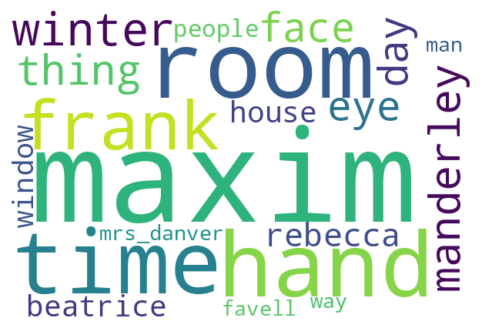

In [ ]:
# Список слов для исключения вручную
exclude_words = {'little', 'old', 'good', 'long', 'great', 'large', 'small', 'know', 'course'}
    # наречие course - артефакт токенизации, посколько удалился часть of

# Фильтруем noun_freq перед передачей в WordCloud
filtered_freq = {word: freq for word, freq in noun_freq.items()
                 if word not in exclude_words}

# Облако слов из отфильтрованного словаря
most_common_words = dict(Counter(filtered_freq).most_common(20))

wc = WordCloud(width=600, height=400, background_color='white', max_words=100)\
     .generate_from_frequencies(most_common_words)

plt.figure(figsize=(8, 4))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

#### Частнотность слова **love**

In [ ]:
# Частота слова "love"
def get_word_freq(target_word):
    freq = word_freq.get(target_word, 0)
    print(f"Частота слова '{target_word}': {freq}")
    return freq

target = 'love'
get_word_freq(target)

Частота слова 'love': 113


113

##### Подсчет по частям речи на предобработанном тексте **(не правильно)**

In [ ]:
def count_love_pos_spacy(text):
    doc = nlp(str(text))
    noun_count = 0
    verb_count = 0
    for token in doc:
        if token.lemma_.lower() == 'love' or token.text.lower() == 'love':
            if token.pos_ == 'NOUN':
                noun_count += 1
            elif token.pos_ == 'VERB' or token.pos_ == 'AUX' :
                verb_count += 1
    return noun_count, verb_count


total_noun, total_verb = 0, 0
for _, row in df_clean.iterrows():
    noun, verb = count_love_pos_spacy(row['clean'])
    total_noun += noun
    total_verb += verb

In [ ]:
from collections import Counter

all_love_pos = Counter()
for _, row in df_clean.iterrows():
    doc = nlp(str(row['clean']))
    for token in doc:
        if token.lemma_.lower() == 'love' or token.text.lower() == 'love':
            all_love_pos[token.pos_] += 1

print(all_love_pos)

Counter({'NOUN': 96, 'PROPN': 13, 'VERB': 5})


In [ ]:
love_pos_summary = pd.DataFrame([{
    'love_noun': total_noun,
    'love_verb': total_verb
}])

love_pos_summary

,love_noun,love_verb
0,96,5


##### Подсчет по частям речи на исходном тексте

In [ ]:
# Убираем служебные строки
df_raw = df.copy()
df_raw = df_raw[~df_raw['input'].str.strip().str.lower().str.match(r'^chapter(\s+\S+)?$')]
df_raw = df_raw[df_raw['input'].str.strip().str.lower() != 'end']
df_raw = df_raw.reset_index(drop=True)

# Частеречный анализ love на исходном тексте
def count_love_pos_spacy(text):
    doc = nlp(str(text))
    noun_count = 0
    verb_count = 0
    for token in doc:
        if token.lemma_.lower() == 'love':
            if token.tag_.startswith('NN'):
                noun_count += 1
            elif token.tag_.startswith('VB'):
                verb_count += 1
    return noun_count, verb_count


total_noun, total_verb = 0, 0
for _, row in df_raw.iterrows():
    noun, verb = count_love_pos_spacy(row['input'])
    total_noun += noun
    total_verb += verb

love_pos_summary = pd.DataFrame([{
    'love_noun': total_noun,
    'love_verb': total_verb
}])
love_pos_summary

,love_noun,love_verb
0,36,77




> Из-за предобработки текста плохо определяются части речи, поэтому было принято использовать изначальный текст




### Коллокация

In [ ]:
def analyze_syntagmatic_clean(df, target_word='love', window_size=3):
    # Собираем все токены из предобработанного датафрейма
    tokens = []
    for _, row in df.iterrows():
        tokens.extend(str(row['clean']).split())

    # Частеречная разметка (на лемматизированных токенах)
    tagged = pos_tag(tokens)

    # Сбор контекстов целевого слова
    contexts = []
    for i, word in enumerate(tokens):
        if word == target_word:
            start = max(0, i - window_size)
            end = min(len(tokens), i + window_size + 1)
            contexts.append(tagged[start:end])

    # Коллокации через PMI
    bigram_measures = BigramAssocMeasures()
    finder = BigramCollocationFinder.from_words(tokens)
    finder.apply_freq_filter(2)

    scored_collocations = finder.score_ngrams(bigram_measures.pmi)
    target_collocations = [
        (bigram, score) for bigram, score in scored_collocations
        if target_word in bigram
    ]
    target_collocations.sort(key=lambda x: x[1], reverse=True)
    top_collocations = [bigram for bigram, score in target_collocations[:20]]

    return {'collocations': top_collocations}


result = analyze_syntagmatic_clean(df_clean, target_word='love')

print("Коллокации с 'love':")
print(result['collocations'])


Коллокации с 'love':
[('flatter', 'love'), ('sign', 'love'), ('love', 'husband'), ('love', 'whisper'), ('love', 'person'), ('love', 'world'), ('love', 'rebecca'), ('love', 'marry'), ('marry', 'love'), ('love', 'love'), ('love', 'mr'), ('sort', 'love'), ('love', 'will'), ('love', 'man'), ('rebecca', 'love'), ('eye', 'love'), ('maxim', 'love'), ('man', 'love'), ('ask', 'love'), ('think', 'love')]


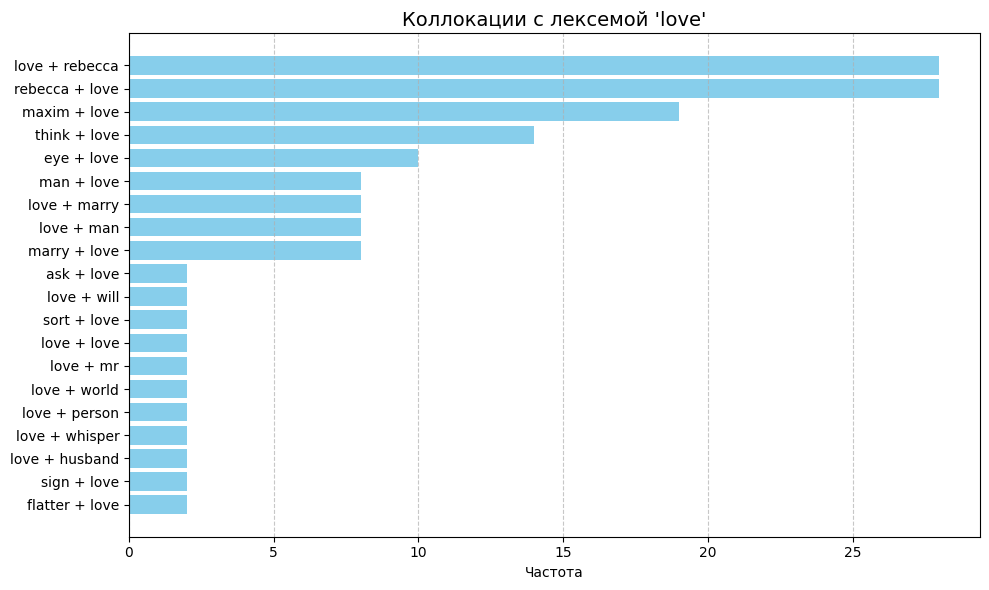

In [ ]:
def visualize_results(results):

    plt.figure(figsize=(10, 6))
    if results['collocations']:
        colloc_data = [(c[0], c[1]) for c in results['collocations']]
        colloc_labels = [f"{w1} + {w2}" for w1, w2 in colloc_data]

        # Получаем реальные частоты из word_context
        word_freq_dict = dict(results['word_context'])
        colloc_counts = [
            word_freq_dict.get(w1, 1) + word_freq_dict.get(w2, 1)
            for w1, w2 in colloc_data
        ]

        sorted_indices = np.argsort(colloc_counts)
        sorted_labels = [colloc_labels[i] for i in sorted_indices]
        sorted_counts = [colloc_counts[i] for i in sorted_indices]

        plt.barh(sorted_labels, sorted_counts, color='skyblue')
        plt.xlabel('Частота')
        plt.title("Коллокации с лексемой 'love'", fontsize=14)
        plt.grid(axis='x', linestyle='--', alpha=0.7)
    else:
        plt.text(0.5, 0.5, "Коллокации не найдены", ha='center', va='center', fontsize=14)
    plt.tight_layout()
    plt.show()




# Запуск
result = analyze_syntagmatic_clean(df_clean, target_word='love')
visualize_results(result)

### Частеречное окружение



In [ ]:
WINDOW = 3

def get_love_contexts_en(df, window: int = WINDOW):
    """
    Извлекает контекстные окна вокруг love-NOUN и love-VERB из df_clean.
    df    — датафрейм с колонкой 'clean' (лемматизированный текст)
    window — размер контекстного окна (±n слов)
    Возвращает два списка соседних лемм: для NOUN и для VERB.
    """
    noun_context = []
    verb_context = []

    EN_STOP = {
        'not', 'i', 'de', 're', 've', 'm', 's',
        'the', 'a', 'an', 'it', 'be', 'do',
        'that', 'this', 'so', 'just', 'get'
    }

    for _, row in df.iterrows():
        doc = nlp(str(row['clean']))
        tokens = list(doc)
        for i, token in enumerate(tokens):
            if token.lemma_.lower() != 'love' and token.text.lower() != 'love':
                continue

            left  = tokens[max(0, i - window): i]
            right = tokens[i + 1: i + 1 + window]

            neighbors = [
                t.lemma_.lower() for t in left + right
                if not t.is_punct
                and not t.is_space
                and t.lemma_.lower() not in EN_STOP
                and len(t.lemma_) > 1
                and t.lemma_.lower() != 'love'
            ]

            if token.tag_.startswith('NN'):
                noun_context.extend(neighbors)
            elif token.tag_.startswith('VB'):
                verb_context.extend(neighbors)

    return noun_context, verb_context


# Запуск
noun_ctx, verb_ctx = get_love_contexts_en(df_clean)

print(f"Контекстов love-NOUN: {len(noun_ctx)}")
print(f"Контекстов love-VERB: {len(verb_ctx)}")
print(f"\nТоп-20 слов рядом с love (сущ.): {Counter(noun_ctx).most_common(20)}")
print(f"\nТоп-20 слов рядом с love (глаг.): {Counter(verb_ctx).most_common(20)}")



Контекстов love-NOUN: 537
Контекстов love-VERB: 28

Топ-20 слов рядом с love (сущ.): [('say', 27), ('rebecca', 22), ('maxim', 18), ('know', 16), ('think', 11), ('manderley', 10), ('thing', 8), ('want', 7), ('eye', 7), ('come', 6), ('go', 6), ('marry', 6), ('man', 6), ('winter', 6), ('look', 6), ('face', 6), ('time', 5), ('tell', 5), ('forget', 5), ('like', 5)]

Топ-20 слов рядом с love (глаг.): [('rebecca', 3), ('say', 2), ('think', 2), ('remind', 1), ('wonder', 1), ('suddenly', 1), ('voice', 1), ('sort', 1), ('beatrice', 1), ('play', 1), ('charade', 1), ('important', 1), ('world', 1), ('fact', 1), ('sick', 1), ('hurt', 1), ('desperate', 1), ('person', 1), ('man', 1), ('wife', 1)]


In [ ]:
EN_STOP = {
        'not', 'i', 'de', 're', 've', 'm', 's',
        'the', 'a', 'an', 'it', 'be', 'do',
        'that', 'this', 'so', 'just', 'get'
}
for w in EN_STOP:
    eng_stopwords.add(w)

In [ ]:
WINDOW = 5

def get_love_contexts_en(df_raw, window: int = WINDOW):
    """
    Анализирует исходный текст (df_raw, колонка 'input') для корректного теггинга.
    В контекст записываются леммы соседних токенов — чтобы словоформы объединялись.
    """
    noun_context = []
    verb_context = []

    EN_STOP = eng_stopwords

    for _, row in df_raw.iterrows():
        doc = nlp(str(row['input']))  # ← исходный текст
        tokens = list(doc)
        for i, token in enumerate(tokens):
            if token.lemma_.lower() != 'love':
                continue

            left  = tokens[max(0, i - window): i]
            right = tokens[i + 1: i + 1 + window]

            neighbors = [
                t.lemma_.lower() for t in left + right  # ← леммы соседей
                if not t.is_punct
                and not t.is_space
                and t.lemma_.lower() not in EN_STOP
                and len(t.lemma_) > 1
                and t.lemma_.lower() != 'love'
            ]

            # tag_ корректен на исходном тексте
            if token.tag_.startswith('NN'):
                noun_context.extend(neighbors)
            elif token.tag_.startswith('VB'):
                verb_context.extend(neighbors)

    return noun_context, verb_context


# Запуск — передаём исходный df
noun_ctx, verb_ctx = get_love_contexts_en(df)

print(f"Контекстов love-NOUN: {len(noun_ctx)}")
print(f"Контекстов love-VERB: {len(verb_ctx)}")
print(f"\nТоп-20 слов рядом с love (сущ.):")
print(Counter(noun_ctx).most_common(20))
print(f"\nТоп-20 слов рядом с love (глаг.):")
print(Counter(verb_ctx).most_common(20))

Контекстов love-NOUN: 82
Контекстов love-VERB: 199

Топ-20 слов рядом с love (сущ.):
[('maxim', 4), ('say', 3), ('give', 3), ('make', 2), ('much', 2), ('anything', 2), ('perhaps', 2), ('flatter', 2), ('rebecca', 2), ('always', 2), ('sort', 2), ('see', 2), ('least', 1), ('confidence', 1), ('something', 1), ('mother', 1), ('fever', 1), ('first', 1), ('violent', 1), ('behind', 1)]

Топ-20 слов рядом с love (глаг.):
[('never', 15), ('rebecca', 12), ('maxim', 11), ('say', 9), ('know', 8), ('would', 6), ('much', 5), ('think', 4), ('manderley', 4), ('man', 3), ('want', 3), ('garden', 3), ('anything', 3), ('mr', 3), ('winter', 3), ('frank', 3), ('hold', 2), ('rather', 2), ('come', 2), ('begin', 2)]


In [ ]:
TOP_N = 20

en_noun_freq = Counter(noun_ctx).most_common(TOP_N)
en_verb_freq = Counter(verb_ctx).most_common(TOP_N)

# Вывод таблиц
for label, freq in [('EN love-NOUN', en_noun_freq),
                     ('EN love-VERB', en_verb_freq)]:
    df_freq = pd.DataFrame(freq, columns=['word', 'freq'])
    print(f"\n=== {label} ===")
    print(df_freq.to_string(index=False))



=== EN love-NOUN ===
      word  freq
     maxim     4
       say     3
      give     3
      make     2
      much     2
  anything     2
   perhaps     2
   flatter     2
   rebecca     2
    always     2
      sort     2
       see     2
     least     1
confidence     1
 something     1
    mother     1
     fever     1
     first     1
   violent     1
    behind     1

=== EN love-VERB ===
     word  freq
    never    15
  rebecca    12
    maxim    11
      say     9
     know     8
    would     6
     much     5
    think     4
manderley     4
      man     3
     want     3
   garden     3
 anything     3
       mr     3
   winter     3
    frank     3
     hold     2
   rather     2
     come     2
    begin     2


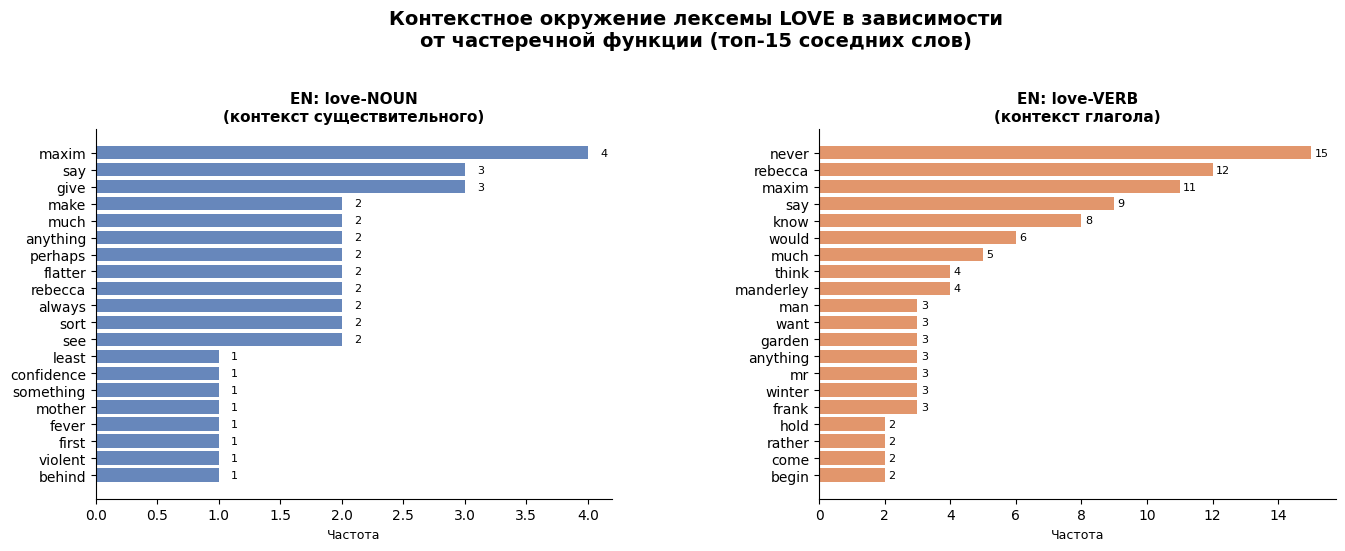

In [ ]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Контекстное окружение лексемы LOVE в зависимости\nот частеречной функции (топ-20 соседних слов)',
             fontsize=14, fontweight='bold', y=0.98)

gs = GridSpec(2, 2, figure=fig, hspace=0.5, wspace=0.4)

panels = [
    (en_noun_freq, 'EN: love-NOUN\n(контекст существительного)', '#4C72B0', gs[0, 0]),
    (en_verb_freq, 'EN: love-VERB\n(контекст глагола)',           '#DD8452', gs[0, 1]),

]

for freq_data, title, color, grid_pos in panels:
    ax = fig.add_subplot(grid_pos)
    if not freq_data:
        ax.text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontsize=11, fontweight='bold')
        continue
    words  = [w for w, _ in freq_data][::-1]
    counts = [c for _, c in freq_data][::-1]
    bars = ax.barh(words, counts, color=color, alpha=0.85)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Частота', fontsize=9)
    # Подписи значений
    for bar, val in zip(bars, counts):
        ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.show()

## **Обучение векторной модели**

In [ ]:
cores = multiprocessing.cpu_count()

In [ ]:
workers = cores - 1  # Оставь одно ядро для ОС

In [ ]:
fasttext_model = FastText(
    sentences=sentences,
    min_count=3,
    window=5,
    vector_size=200,
    sg=1,
    sample=1e-3,
    alpha=0.025,
    min_alpha=0.0001,
    negative=10,
    workers=workers,
    min_n=3,
    max_n=4,
    epochs=15,
    seed=42
)

In [ ]:
# Материализуем — делается один раз
sentences = [bigram[sentence] for sentence in sentences]

# Проверка что не пустой
print(f"Предложений: {len(sentences)}")
print(f"Пример: {sentences[0][:10]}")

In [ ]:
list_sentences = list(sentences)  # иногда это помогает преобразовать обратно
print(list_sentences[:3])

Проверяем обучение модели

* Ближайшие соседние векторы к векторам лексем в пространстве эмбеддингов FastText

In [ ]:
fasttext_model.wv.most_similar(positive=["love"])

[('lovely', 0.8954780101776123),
 ('prove', 0.8798437118530273),
 ('lover', 0.8657567501068115),
 ('approve', 0.8325091600418091),
 ('live', 0.819053590297699),
 ('believe', 0.803919792175293),
 ('attractive', 0.7925639748573303),
 ('relieve', 0.7887802124023438),
 ('motive', 0.7833022475242615),
 ('revive', 0.777988851070404)]

In [ ]:
fasttext_model.wv.most_similar(positive=["rebecca"])

[('crypt', 0.8583722114562988),
 ('cousin', 0.7958471775054932),
 ('deny', 0.7887879014015198),
 ('kill', 0.7848135828971863),
 ('unknown', 0.7803678512573242),
 ('relax', 0.7735273241996765),
 ('identify', 0.7672497630119324),
 ('believe', 0.7560300827026367),
 ('prove', 0.7556357383728027),
 ('idea', 0.7531232833862305)]

In [ ]:
fasttext_model.wv.most_similar(positive=["maxim"])

[('retire', 0.8487658500671387),
 ('frank', 0.838286280632019),
 ('ah', 0.8377566337585449),
 ('quickly', 0.8373780250549316),
 ('asylum', 0.8324033617973328),
 ('helen', 0.8291293382644653),
 ('frank_crawley', 0.8283889889717102),
 ('eagerly', 0.8283886313438416),
 ('embarrassed', 0.8272324204444885),
 ('taxi', 0.82381671667099)]

* Ближайшие соседние векторы к результирующему вектору *maxim + rebecca − love* в пространстве эмбеддингов FastText

In [ ]:
fasttext_model.wv.most_similar(positive=["maxim", "rebecca"], negative=["love"])

[('quick', 0.7023314833641052),
 ('repeat', 0.6993010640144348),
 ('reception', 0.6818045377731323),
 ('relax', 0.6810362935066223),
 ('dick', 0.6777132153511047),
 ('solution', 0.6773535013198853),
 ('record', 0.677201509475708),
 ('decide', 0.6744717955589294),
 ('refuse', 0.6723407506942749),
 ('frighten', 0.6719186305999756)]

In [ ]:
fasttext_model.wv.most_similar(positive=["narrator", "winter"], negative=["love"])

[('alabaster', 0.7995103597640991),
 ('master', 0.781998336315155),
 ('seacock', 0.7607904076576233),
 ('jam', 0.7589510679244995),
 ('key', 0.746929943561554),
 ('porter', 0.7412490844726562),
 ('bannister', 0.7408727407455444),
 ('gentleman', 0.7385820150375366),
 ('cluster', 0.7324281930923462),
 ('visitor', 0.7269690632820129)]

* Семантическая близость пары

In [ ]:
print(fasttext_model.wv.similarity("maxim", "rebecca"))

0.67339844


In [ ]:
print(fasttext_model.wv.similarity("love", "rebecca"))

0.7360055


In [ ]:
print(fasttext_model.wv.similarity("love", "maxim"))

0.63226753


## Моделирование лексико-семантического поля

In [ ]:
def cluster_baseword(model, baseword, topn=80, n_clusters=6, min_len=3):
    """
    Выделяет ближайшие к baseword слова и кластеризует их.

    Возвращает:
    words      – список слов,
    vectors    – исходные векторы (d-мерные),
    labels     – метки кластеров (по 2D),
    vectors_2d  – векторы после t-SNE (2D).
    """
    if baseword not in model.wv.key_to_index:
        print(f"'{baseword}' не найдено в словаре модели.")
        return None, None, None, None

    similarwords = [baseword] + [
        word for word, _ in model.wv.most_similar(baseword, topn=topn)
    ]
    words = [
        w for w in similarwords
        if w in model.wv.key_to_index
        and len(w) >= min_len
        and w.isalpha()
    ]

    vectors = np.array([model.wv[w] for w in words])

    # Кластеризация — по исходным векторам ✅
    kmeans = KMeans(n_clusters=min(n_clusters, len(words)), n_init=10, random_state=42)
    labels = kmeans.fit_predict(vectors)

    # t-SNE — только для визуализации
    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=min(25, len(vectors) - 1),
        max_iter=1000,
        learning_rate=200,
        n_jobs=-1
    )
    vectors_2d = tsne.fit_transform(vectors)

    return words, vectors, labels, vectors_2d

Определение оптимального числа кластеров

In [ ]:
words, vectors, labels, vectors2d = cluster_baseword(fasttext_model, 'love', topn=80)



> Метрики считаем по vectors исходной размерности, vectors2d нужны только для визуализации!

In [ ]:
# Подбор k — по исходным векторам
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_k = kmeans.fit_predict(vectors)  # ← исходные, не vectors2d
    score = silhouette_score(vectors, labels_k, metric='cosine')
    print(f"k={k}: silhouette = {score:.3f}")

kmeans_final = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_final = kmeans_final.fit_predict(vectors)  # ← исходные

k=2: silhouette = 0.280
k=3: silhouette = 0.221
k=4: silhouette = 0.151
k=5: silhouette = 0.135
k=6: silhouette = 0.137
k=7: silhouette = 0.165
k=8: silhouette = 0.133
k=9: silhouette = 0.125
k=10: silhouette = 0.093


In [ ]:
def visualize_semantic_field(model, base_word, topn=80, lang='en'):
    words, vectors, labels, vectors2d = cluster_baseword(
        model, base_word, topn=topn, n_clusters=3
    )
    if words is None:
        return

    CLUSTER_COLORS = ['#4C72B0', '#DD8452', '#55A868']  # синий, оранжевый, зелёный
    point_colors = [CLUSTER_COLORS[label] for label in labels]

    fig, ax = plt.subplots(figsize=(18, 13))

    # Единственный scatter — цвета из CLUSTER_COLORS, привязанных к меткам KMeans
    ax.scatter(
        vectors2d[:, 0], vectors2d[:, 1],
        c=point_colors,
        alpha=0.85, s=120, edgecolors='black', linewidth=0.4, zorder=2
    )

    texts = []
    for i, word in enumerate(words):
        if word == base_word:
            t = ax.text(
                vectors2d[i, 0], vectors2d[i, 1], word,
                fontsize=15, fontweight='bold', color='darkred',
                bbox=dict(facecolor='lightyellow', alpha=1.0,
                          edgecolor='red', boxstyle='round,pad=0.5', linewidth=2)
            )
        else:
            t = ax.text(
                vectors2d[i, 0], vectors2d[i, 1], word,
                fontsize=13,
                bbox=dict(facecolor='white', alpha=0.75,
                          edgecolor='grey', boxstyle='round,pad=0.3')
            )
        texts.append(t)

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.5),
        force_points=(0.5, 0.5),
        force_text=(0.8, 0.8),
        expand_points=(1.5, 1.5),
        ax=ax
    )

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=CLUSTER_COLORS[i], edgecolor='black', label=f'Кластер {i + 1}')
        for i in range(len(CLUSTER_COLORS))
    ]
    ax.legend(handles=legend_elements, title='Кластеры', loc='lower right',
              framealpha=0.9, fontsize=10, title_fontsize=11)

    plt.title(f"Лексико-семантическое поле слова '{base_word}' ({lang.upper()})",
              fontsize=18, fontweight='bold')
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

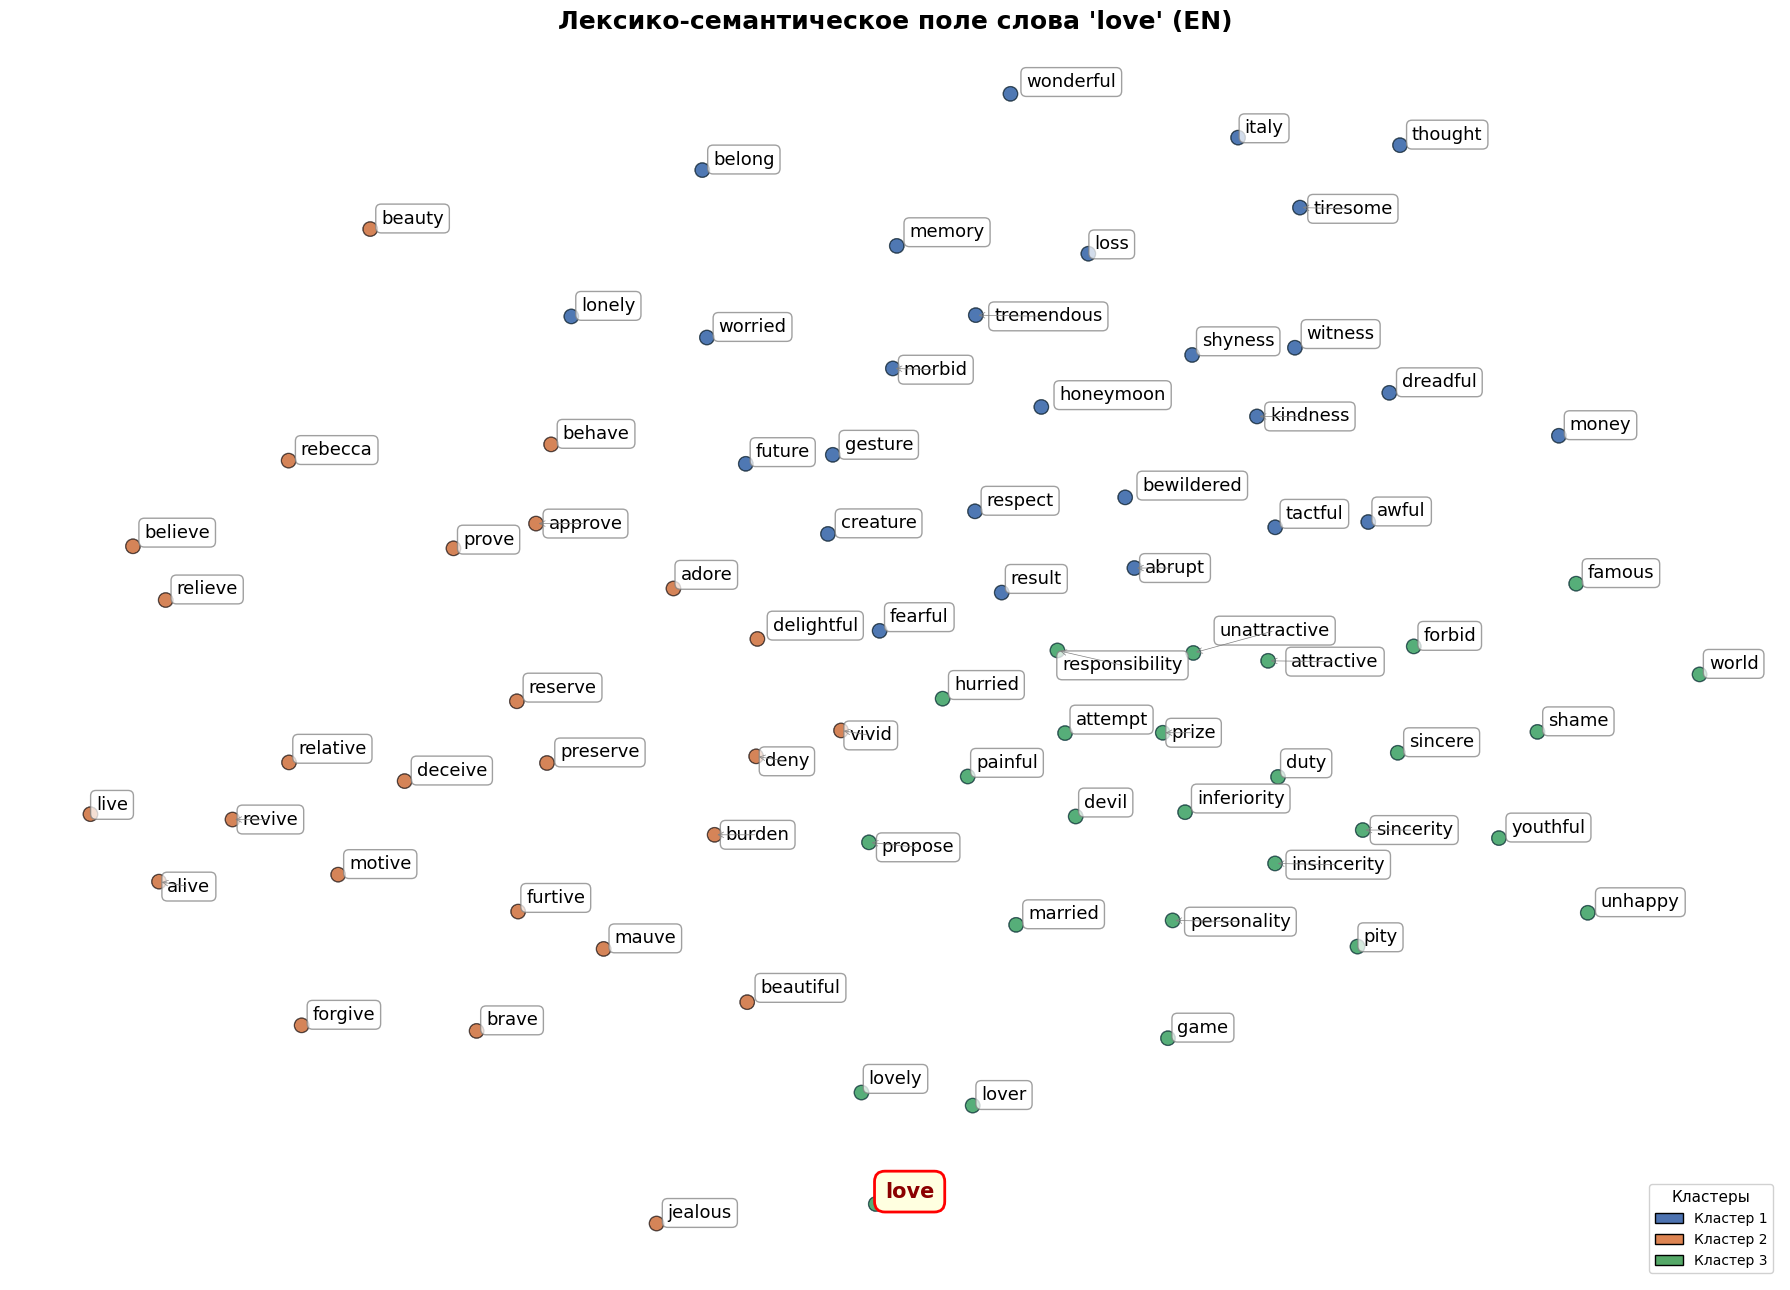

In [ ]:
visualize_semantic_field(fasttext_model, base_word='love', topn=80, lang='en')

### Метрики



> Метрики считаем по vectors исходной размерности, vectors2d нужны только для визуализации!

In [ ]:
print(f"Финальные метрики (k=3):")

# 1. Silhouette Score (чем ближе к 1 — тем лучше кластеры)
sil = silhouette_score(vectors, labels_final, metric='cosine')
print(f"Silhouette score: {sil:.3f}")

# 2. Davies-Bouldin Index (чем меньше — тем лучше)
db  = davies_bouldin_score(vectors, labels_final)
print(f"Davies-Bouldin Index: {db:.3f}")

Финальные метрики (k=3):
Silhouette score: 0.221
Davies-Bouldin Index: 2.321


In [ ]:
# words, vectors, labels — из cluster_baseword
words, vectors, labels, vectors_2d = cluster_baseword(fasttext_model, 'love', topn=80, n_clusters=3)

# concept_vector — вектор слова 'love'
concept_vector = fasttext_model.wv['love']

# 3. Средняя косинусная близость внутри каждого кластера
print("\nСредняя косинусная близость внутри кластеров:")
for cluster_id in sorted(set(labels)):
    cluster_vectors = vectors[labels == cluster_id]
    if len(cluster_vectors) > 1:
        sim_matrix = cosine_similarity(cluster_vectors)
        upper = sim_matrix[np.triu_indices(len(sim_matrix), k=1)]
        print(f"  Кластер {cluster_id}:  количество слов = {len(cluster_vectors)}")
        print(f"    Близость внутри кластера: {upper.mean():.4f}")

# 4. Близость центроида каждого кластера к вектору 'love'
print("\nБлизость кластеров к 'love':")
for cluster_id in sorted(set(labels)):
    cluster_vectors = vectors[labels == cluster_id]
    centroid = cluster_vectors.mean(axis=0)
    sim = cosine_similarity([concept_vector], [centroid])[0][0]
    cluster_words = [w for w, l in zip(words, labels) if l == cluster_id]
    print(f"  Кластер {cluster_id}:")
    print(f"    Примеры слов: {', '.join(cluster_words)}")
    print(f"    Близость к 'love' = {sim:.4f}")


Средняя косинусная близость внутри кластеров:
  Кластер 0:  количество слов = 6
    Близость внутри кластера: 0.7962
  Кластер 1:  количество слов = 22
    Близость внутри кластера: 0.8445
  Кластер 2:  количество слов = 52
    Близость внутри кластера: 0.8798

Близость кластеров к 'love':
  Кластер 0:
    Примеры слов: love, lovely, lover, beauty, beautiful, rebecca
    Близость к 'love' = 0.9245
  Кластер 1:
    Примеры слов: live, motive, revive, relative, deceive, deny, alive, forgive, brave, belong, memory, gesture, reserve, future, furtive, vivid, mauve, preserve, creature, morbid, burden, money
    Близость к 'love' = 0.8125
  Кластер 2:
    Примеры слов: prove, approve, believe, attractive, relieve, unattractive, world, behave, sincerity, italy, unhappy, sincere, forbid, jealous, shame, lonely, fearful, devil, famous, dreadful, responsibility, prize, hurried, personality, adore, tremendous, married, pity, loss, tactful, painful, delightful, tiresome, youthful, wonderful, thoug